# 🧠 Overthinking Level Prediction Model

Predicting Overthinking Level (No/Low/Medium/High) using Random Forest Algorithm
Based on: Age, CGPA, Year of Study, Gender, Course

**Input (Features):**
- Age
- CGPA
- Year of Study
- Gender
- Course

**Output (Target):**
- Overthinking Level (Calculated from Depression + Anxiety + Panic Attack)

## 1️⃣ Import Required Libraries

In [31]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2️⃣ Load Cleaned Dataset

In [6]:
df = pd.read_csv('Student_Mental_Health_Cleaned.csv')
print(f"📊 Dataset loaded!")
print(f"Shape: {df.shape}")
print(f"\n📋 First few rows:")
print(df.head())
print(f"\n🔍 Columns:")
print(df.columns.tolist())

📊 Dataset loaded!
Shape: (101, 8)

📋 First few rows:
  Choose your gender   Age What is your course? Your current year of Study  \
0             Female  18.0          Engineering                     year 1   
1               Male  21.0    Islamic education                     year 2   
2               Male  19.0                  BIT                     Year 1   
3             Female  22.0                 Laws                     year 3   
4               Male  23.0         Mathemathics                     year 4   

  What is your CGPA? Do you have Depression? Do you have Anxiety?  \
0        3.00 - 3.49                     Yes                   No   
1        3.00 - 3.49                      No                  Yes   
2        3.00 - 3.49                     Yes                  Yes   
3        3.00 - 3.49                     Yes                   No   
4        3.00 - 3.49                      No                   No   

  Do you have Panic attack?  
0                       Yes  
1  

## 3️⃣ Create Overthinking Level Target Variable

Ye Depression, Anxiety aur Panic Attack ko combine karke "Overthinking Level" banate hain

In [7]:
df_model = df.copy()

# Function to calculate Overthinking Level
def calculate_overthinking_level(row):
    """
    Calculate Overthinking Level based on mental health conditions
    0 conditions = No Overthinking
    1 condition  = Low Overthinking
    2 conditions = Medium Overthinking
    3 conditions = High Overthinking
    """
    count = 0
    if row['Do you have Depression?'] == 'Yes':
        count += 1
    if row['Do you have Anxiety?'] == 'Yes':
        count += 1
    if row['Do you have Panic attack?'] == 'Yes':
        count += 1
    
    if count == 0:
        return 'No Overthinking'
    elif count == 1:
        return 'Low Overthinking'
    elif count == 2:
        return 'Medium Overthinking'
    else:  # count == 3
        return 'High Overthinking'

# Create Overthinking Level column
df_model['Overthinking_Level'] = df_model.apply(calculate_overthinking_level, axis=1)

print("🧠 Overthinking Level Created!\n")
print("📊 Distribution:")
print(df_model['Overthinking_Level'].value_counts())
print("\n📈 Percentage:")
print((df_model['Overthinking_Level'].value_counts() / len(df_model) * 100).round(2))

print("\n\n📋 Example Data:")
display_cols = ['Do you have Depression?', 'Do you have Anxiety?', 'Do you have Panic attack?', 'Overthinking_Level']
print(df_model[display_cols].head(10).to_string())

🧠 Overthinking Level Created!

📊 Distribution:
Overthinking_Level
No Overthinking        37
Low Overthinking       36
Medium Overthinking    18
High Overthinking      10
Name: count, dtype: int64

📈 Percentage:
Overthinking_Level
No Overthinking        36.63
Low Overthinking       35.64
Medium Overthinking    17.82
High Overthinking       9.90
Name: count, dtype: float64


📋 Example Data:
  Do you have Depression? Do you have Anxiety? Do you have Panic attack?   Overthinking_Level
0                     Yes                   No                       Yes  Medium Overthinking
1                      No                  Yes                        No     Low Overthinking
2                     Yes                  Yes                       Yes    High Overthinking
3                     Yes                   No                        No     Low Overthinking
4                      No                   No                        No      No Overthinking
5                      No                   

## 4️⃣ Data Preprocessing

In [8]:
# Separate features and target
# FEATURES: Age, CGPA, Year, Gender, Course
# TARGET: Overthinking_Level

X = df_model.drop(columns=[
    'Overthinking_Level',
    'Do you have Depression?',
    'Do you have Anxiety?',
    'Do you have Panic attack?'
])
y = df_model['Overthinking_Level']

print("✅ Data Separation Complete!\n")
print(f"📌 Features (Input): {X.columns.tolist()}")
print(f"📊 X shape: {X.shape}")
print(f"📊 y shape: {y.shape}")

# Encode categorical variables in features
label_encoders = {}
categorical_cols = X.select_dtypes(include=['object']).columns

print(f"\n🔄 Encoding categorical features:")
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    print(f"   ✅ {col}")

# Encode target variable
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

print(f"\n📋 Overthinking Level Mapping:")
for i, label in enumerate(target_encoder.classes_):
    print(f"   {i} = {label}")

print(f"\n✅ All preprocessing complete!")
print(f"Final X shape: {X.shape}")
print(f"Final y shape: {y.shape}")

✅ Data Separation Complete!

📌 Features (Input): ['Choose your gender', 'Age', 'What is your course?', 'Your current year of Study', 'What is your CGPA?']
📊 X shape: (101, 5)
📊 y shape: (101,)

🔄 Encoding categorical features:
   ✅ Choose your gender
   ✅ What is your course?
   ✅ Your current year of Study
   ✅ What is your CGPA?

📋 Overthinking Level Mapping:
   0 = High Overthinking
   1 = Low Overthinking
   2 = Medium Overthinking
   3 = No Overthinking

✅ All preprocessing complete!
Final X shape: (101, 5)
Final y shape: (101,)


## 5️⃣ Train-Test Split (80-20)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("✅ Data split completed (80-20)!\n")
print(f"📊 Training Set: {X_train.shape[0]} samples")
print(f"📊 Testing Set: {X_test.shape[0]} samples")

print(f"\n🎯 Training Target Distribution:")
for i, label in enumerate(target_encoder.classes_):
    count = (y_train == i).sum()
    print(f"   {label}: {count}")

print(f"\n🎯 Testing Target Distribution:")
for i, label in enumerate(target_encoder.classes_):
    count = (y_test == i).sum()
    print(f"   {label}: {count}")

✅ Data split completed (80-20)!

📊 Training Set: 80 samples
📊 Testing Set: 21 samples

🎯 Training Target Distribution:
   High Overthinking: 8
   Low Overthinking: 29
   Medium Overthinking: 14
   No Overthinking: 29

🎯 Testing Target Distribution:
   High Overthinking: 2
   Low Overthinking: 7
   Medium Overthinking: 4
   No Overthinking: 8


## 6️⃣ Build & Train Random Forest Model

In [10]:
print("🌲 Building Random Forest Model for Multi-class Classification...\n")

# Create and train model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("✅ Model trained successfully!")
print(f"\n🌲 Model Configuration:")
print(f"   • Algorithm: Random Forest Classifier")
print(f"   • Number of trees: 100")
print(f"   • Max depth: 8")
print(f"   • Task: Multi-class Classification")
print(f"   • Classes: {list(target_encoder.classes_)}")
print(f"   • Features: {list(X.columns)}")

🌲 Building Random Forest Model for Multi-class Classification...

✅ Model trained successfully!

🌲 Model Configuration:
   • Algorithm: Random Forest Classifier
   • Number of trees: 100
   • Max depth: 8
   • Task: Multi-class Classification
   • Classes: ['High Overthinking', 'Low Overthinking', 'Medium Overthinking', 'No Overthinking']
   • Features: ['Choose your gender', 'Age', 'What is your course?', 'Your current year of Study', 'What is your CGPA?']


## 7️⃣ Make Predictions

In [22]:
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)
y_test_proba = rf_model.predict_proba(X_test)

print("✅ Predictions made!\n")     
print("📊 Sample Predictions (first 10 test samples):\n")
print(f"{'Sample':<8} {'Actual':<20} {'Predicted':<20} {'Confidence':<12}")
print("-" * 60)

print(y_test)

for i in range(min(21, len(y_test_pred))):
    # print(int(y_test[i]))
    actual = target_encoder.classes_[int(y_test[i])]
    predicted = target_encoder.classes_[y_test_pred[i]]
    confidence = y_test_proba[i].max()
    print(f"{i+1:<8} {actual:<20} {predicted:<20} {confidence:.2%}")

✅ Predictions made!

📊 Sample Predictions (first 10 test samples):

Sample   Actual               Predicted            Confidence  
------------------------------------------------------------
[3 2 3 2 1 0 3 3 1 3 3 1 1 3 1 1 2 3 0 1 2]
1        No Overthinking      No Overthinking      57.02%
2        Medium Overthinking  Low Overthinking     58.14%
3        No Overthinking      Low Overthinking     56.65%
4        Medium Overthinking  Medium Overthinking  46.57%
5        Low Overthinking     Low Overthinking     36.36%
6        High Overthinking    No Overthinking      50.89%
7        No Overthinking      Low Overthinking     47.95%
8        No Overthinking      Low Overthinking     43.12%
9        Low Overthinking     Medium Overthinking  39.50%
10       No Overthinking      No Overthinking      57.74%
11       No Overthinking      No Overthinking      34.38%
12       Low Overthinking     No Overthinking      47.85%
13       Low Overthinking     Low Overthinking     33.64%
14       

## 8️⃣ Model Evaluation

In [24]:
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
cm = confusion_matrix(y_test, y_test_pred)

print("=" * 70)
print("📊 MODEL PERFORMANCE METRICS".center(70))
print("=" * 70)

print(f"\n🎯 ACCURACY:")
print(f"   Training Accuracy: {train_accuracy:.2%}")
print(f"   Testing Accuracy:  {test_accuracy:.2%}")

print(f"\n🔍 CONFUSION MATRIX (Test Set):")
print(cm)

print(f"\n📋 CLASSIFICATION REPORT (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=target_encoder.classes_))

print("=" * 70)

                     📊 MODEL PERFORMANCE METRICS                      

🎯 ACCURACY:
   Training Accuracy: 82.50%
   Testing Accuracy:  38.10%

🔍 CONFUSION MATRIX (Test Set):
[[0 1 0 1]
 [0 3 1 3]
 [0 2 1 1]
 [0 4 0 4]]

📋 CLASSIFICATION REPORT (Test Set):
                     precision    recall  f1-score   support

  High Overthinking       0.00      0.00      0.00         2
   Low Overthinking       0.30      0.43      0.35         7
Medium Overthinking       0.50      0.25      0.33         4
    No Overthinking       0.44      0.50      0.47         8

           accuracy                           0.38        21
          macro avg       0.31      0.29      0.29        21
       weighted avg       0.36      0.38      0.36        21



## 9️⃣ Feature Importance

In [13]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n🎯 FEATURE IMPORTANCE (Which features matter most):")
print("=" * 50)
for idx, row in feature_importance.iterrows():
    print(f"{row['Feature']:30s} : {row['Importance']:.4f} {'█' * int(row['Importance'] * 50)}")

print("\n📌 Top 3 Most Important Features:")
for i, (idx, row) in enumerate(feature_importance.head(3).iterrows(), 1):
    print(f"   {i}. {row['Feature']} ({row['Importance']:.2%})")


🎯 FEATURE IMPORTANCE (Which features matter most):
What is your course?           : 0.3796 ██████████████████
Your current year of Study     : 0.2230 ███████████
Age                            : 0.2112 ██████████
What is your CGPA?             : 0.1150 █████
Choose your gender             : 0.0712 ███

📌 Top 3 Most Important Features:
   1. What is your course? (37.96%)
   2. Your current year of Study (22.30%)
   3. Age (21.12%)


## 🔟 Visualizations

✅ Visualizations created and saved as 'Overthinking_Level_Analysis.png'


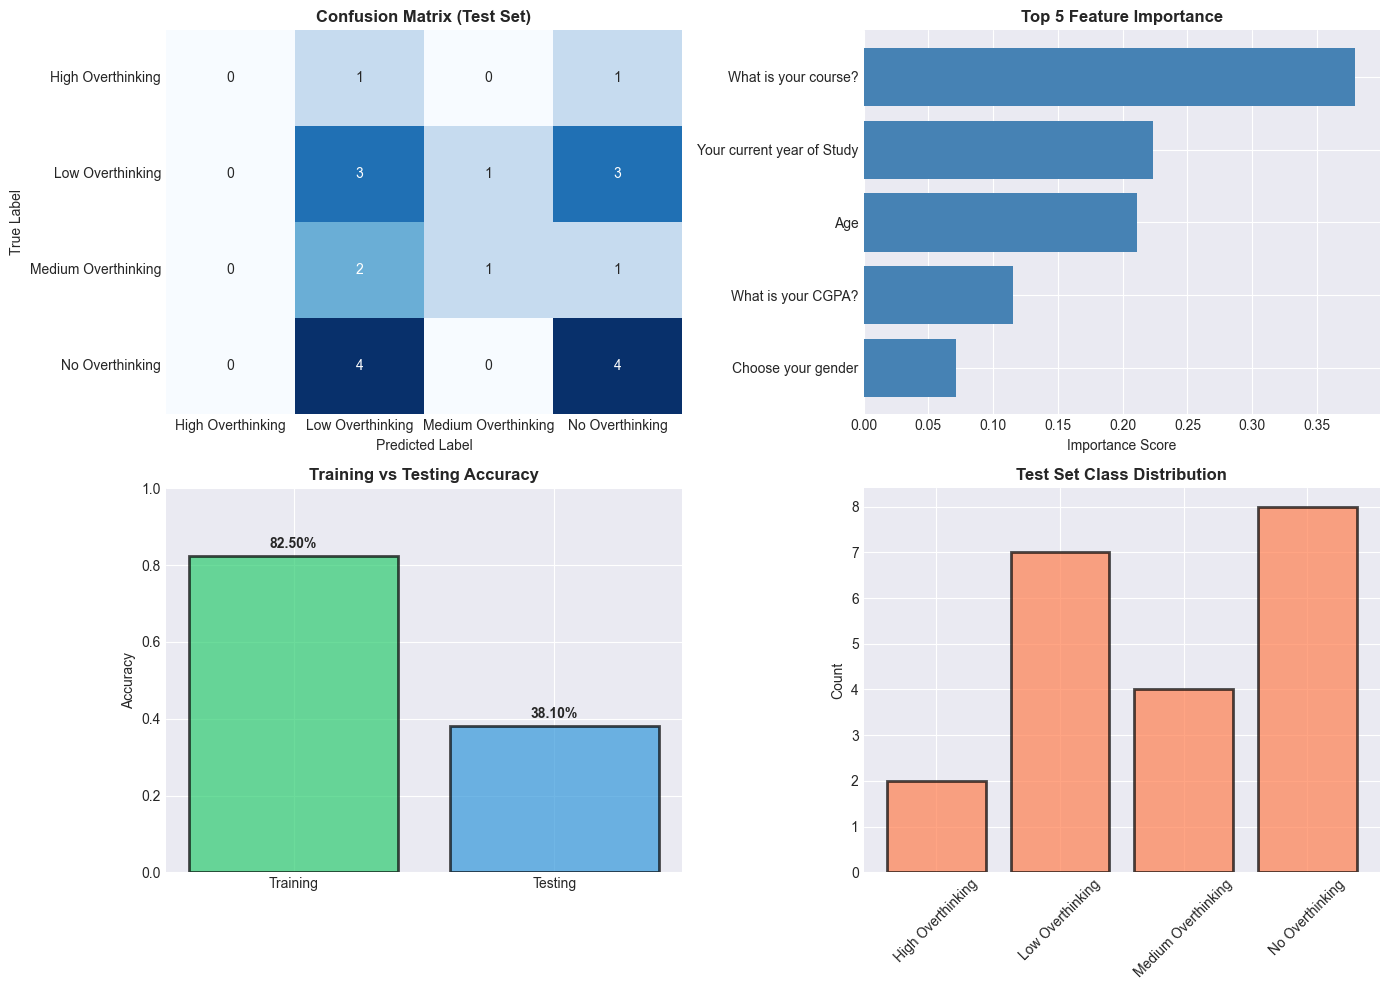

In [14]:
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0], cbar=False,
            xticklabels=target_encoder.classes_, yticklabels=target_encoder.classes_)
axes[0,0].set_title('Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('True Label')
axes[0,0].set_xlabel('Predicted Label')

# 2. Feature Importance
top_features = feature_importance.head(5)
axes[0,1].barh(top_features['Feature'], top_features['Importance'], color='steelblue')
axes[0,1].set_xlabel('Importance Score')
axes[0,1].set_title('Top 5 Feature Importance', fontsize=12, fontweight='bold')
axes[0,1].invert_yaxis()

# 3. Accuracy Comparison
categories = ['Training', 'Testing']
accuracies = [train_accuracy, test_accuracy]
colors = ['#2ecc71', '#3498db']
axes[1,0].bar(categories, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[1,0].set_ylabel('Accuracy')
axes[1,0].set_title('Training vs Testing Accuracy', fontsize=12, fontweight='bold')
axes[1,0].set_ylim([0, 1])
for i, v in enumerate(accuracies):
    axes[1,0].text(i, v + 0.02, f'{v:.2%}', ha='center', fontweight='bold')

# 4. Class Distribution
class_counts = pd.Series(y_test).value_counts().sort_index()
class_labels = [target_encoder.classes_[i] for i in class_counts.index]
axes[1,1].bar(class_labels, class_counts.values, color='coral', alpha=0.7, edgecolor='black', linewidth=2)
axes[1,1].set_ylabel('Count')
axes[1,1].set_title('Test Set Class Distribution', fontsize=12, fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('Overthinking_Level_Analysis.png', dpi=300, bbox_inches='tight')
print("✅ Visualizations created and saved as 'Overthinking_Level_Analysis.png'")
plt.show()

## 🎯 Final Summary

In [ ]:
print("\n" + "*"*70)
print("\n🧠 OVERTHINKING LEVEL PREDICTION - FINAL SUMMARY".center(70))
print("\n" + "*"*70)

print(f"\n✅ MODEL PERFORMANCE:")
print(f"   • Test Accuracy: {test_accuracy:.2%}")
print(f"   • Training Accuracy: {train_accuracy:.2%}")
print(f"   • Task: Multi-class Classification (4 classes)")

print(f"\n📊 CLASSES:")
for i, label in enumerate(target_encoder.classes_):
    print(f"   {i} = {label}")

print(f"\n🎯 TOP 3 PREDICTIVE FEATURES:")
for i, (idx, row) in enumerate(feature_importance.head(3).iterrows(), 1):
    print(f"   {i}. {row['Feature']} - {row['Importance']:.2%}")

print(f"\n📋 INPUT FEATURES (used for prediction):")
for i, col in enumerate(X.columns, 1):
    print(f"   {i}. {col}")

print(f"\n📊 DATASET STATISTICS:")
print(f"   • Total samples: {len(df)}")
print(f"   • Training samples: {len(X_train)}")
print(f"   • Testing samples: {len(X_test)}")

print(f"\n💾 HOW OVERTHINKING LEVEL IS CALCULATED:")
print(f"   • 0 conditions (No depression, No anxiety, No panic) → No Overthinking")
print(f"   • 1 condition  → Low Overthinking")
print(f"   • 2 conditions → Medium Overthinking")
print(f"   • 3 conditions (All Yes) → High Overthinking")

print("\n" + "*"*70)
print("\n✨ Model Successfully Created!")
print("="*70)


**********************************************************************
           
🧠 OVERTHINKING LEVEL PREDICTION - FINAL SUMMARY           

**********************************************************************

✅ MODEL PERFORMANCE:
   • Test Accuracy: 38.10%
   • Training Accuracy: 82.50%
   • Task: Multi-class Classification (4 classes)

📋 INPUT FEATURES (used for prediction):
   1. Choose your gender
   2. Age
   3. What is your course?
   4. Your current year of Study
   5. What is your CGPA?

📊 DATASET STATISTICS:
   • Total samples: 101
   • Training samples: 80
   • Testing samples: 21

💾 HOW OVERTHINKING LEVEL IS CALCULATED:
   • 0 conditions (No depression, No anxiety, No panic) → No Overthinking
   • 1 condition  → Low Overthinking
   • 2 conditions → Medium Overthinking
   • 3 conditions (All Yes) → High Overthinking

**********************************************************************

✨ Model Successfully Created!
